# Doob WTMC Validation

Latest full-suite status captured by Codex on 2026-03-30:

- `./.venv/bin/pytest -q`
- Result: `23 passed in 94.73s (0:01:34)`

This notebook reruns the requested Doob/PPS validation tests and generates a plot comparing:

- Doob WTMC (`Q_s`)
- Procedure A (`Q_s`)
- Procedure B (`Q_s`)
- Procedure C (`R_zeta`)

It also generates an entanglement-versus-`zeta` sweep and saves a PNG to `outputs/doob_validation/doob_requested_checks.png`.

In [1]:
from pathlib import Path
import subprocess
import numpy as np
import matplotlib.pyplot as plt

from pps_qj.backward_pass import run_gaussian_backward_pass
from pps_qj.doob_wtmc import doob_gaussian_trajectory
from pps_qj.exact_backend import (
    build_exact_spin_chain_model,
    procedure_a_trajectory,
    procedure_b_trajectory,
    procedure_c_local_trajectory,
)
from pps_qj.gaussian_backend import build_gaussian_chain_model, covariance_from_orbitals, entanglement_entropy

ROOT = Path.cwd().resolve()
if not (ROOT / 'pps_qj').exists():
    ROOT = ROOT.parent

OUTPUT_DIR = ROOT / 'outputs' / 'doob_validation'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PLOT_PATH = OUTPUT_DIR / 'doob_requested_checks.png'
ROOT, PLOT_PATH

(PosixPath('/Users/catlover1337/Documents/ppsQJ_m2'),
 PosixPath('/Users/catlover1337/Documents/ppsQJ_m2/outputs/doob_validation/doob_requested_checks.png'))

In [2]:
requested = subprocess.run(
    [str(ROOT / '.venv' / 'bin' / 'pytest'), 'tests/test_doob_wtmc.py', '-q'],
    cwd=ROOT,
    capture_output=True,
    text=True,
    check=False,
)
print(requested.stdout)
if requested.stderr:
    print(requested.stderr)
print('exit_code =', requested.returncode)

.........                                                                [100%]
9 passed in 72.66s (0:01:12)

exit_code = 0


PosixPath('/Users/catlover1337/Documents/ppsQJ_m2/outputs/doob_validation/doob_requested_checks.png')

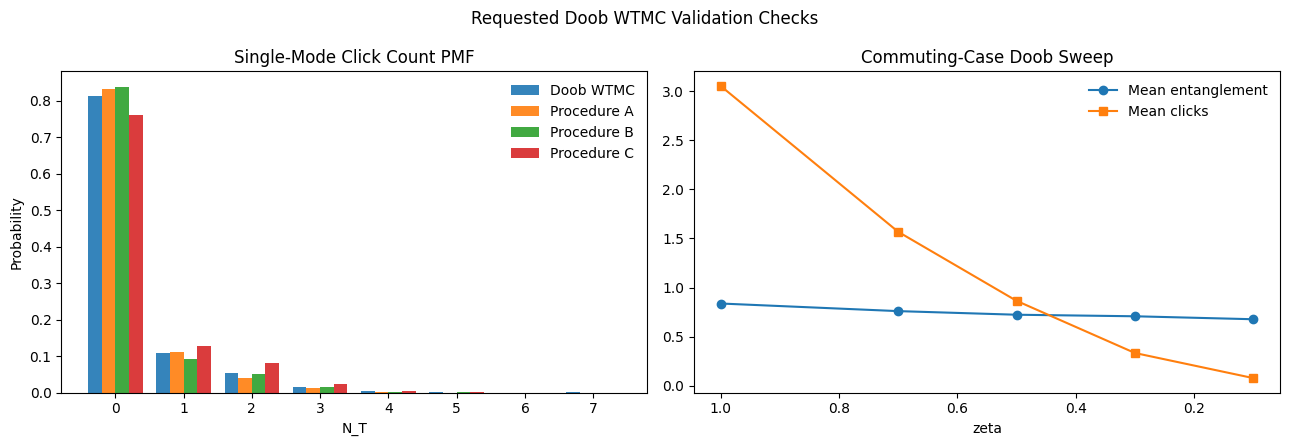

In [3]:
zeta = 0.5
T = 2.0
gamma = 1.0
n_single = 1200

exact = build_exact_spin_chain_model(L=2, w=0.0, gamma_m=gamma)
gauss = build_gaussian_chain_model(L=2, w=0.0, gamma_m=gamma)
backward = run_gaussian_backward_pass(gauss, T=T, zeta=zeta, sample_points=65)

def counts_doob(seed: int) -> np.ndarray:
    rng = np.random.default_rng(seed)
    return np.array([doob_gaussian_trajectory(gauss, backward, T, zeta, rng).n_jumps for _ in range(n_single)], dtype=int)

def counts_exact(fn, seed: int) -> np.ndarray:
    rng = np.random.default_rng(seed)
    return np.array([fn(exact, T, zeta, rng).n_jumps for _ in range(n_single)], dtype=int)

doob_counts = counts_doob(10)
a_counts = counts_exact(procedure_a_trajectory, 11)
b_counts = counts_exact(procedure_b_trajectory, 12)
c_counts = counts_exact(procedure_c_local_trajectory, 13)

def pmf(counts: np.ndarray) -> np.ndarray:
    hist = np.bincount(counts, minlength=int(counts.max()) + 1).astype(float)
    return hist / hist.sum()

pmfs = {
    'Doob WTMC': pmf(doob_counts),
    'Procedure A': pmf(a_counts),
    'Procedure B': pmf(b_counts),
    'Procedure C': pmf(c_counts),
}

zeta_sweep = [1.0, 0.7, 0.5, 0.3, 0.1]
entropy_means = []
click_means = []
for z in zeta_sweep:
    model = build_gaussian_chain_model(L=4, w=0.0, gamma_m=1.0)
    back = run_gaussian_backward_pass(model, T=2.0, zeta=z, sample_points=65)
    rng = np.random.default_rng(int(1000 * z) + 5)
    entropies = []
    clicks = []
    for _ in range(250):
        tr = doob_gaussian_trajectory(model, back, 2.0, z, rng)
        entropies.append(entanglement_entropy(covariance_from_orbitals(tr.final_state), 2))
        clicks.append(tr.n_jumps)
    entropy_means.append(float(np.mean(entropies)))
    click_means.append(float(np.mean(clicks)))

max_len = max(len(v) for v in pmfs.values())
x = np.arange(max_len)
width = 0.2

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for idx, (label, values) in enumerate(pmfs.items()):
    padded = np.pad(values, (0, max_len - len(values)))
    axes[0].bar(x + (idx - 1.5) * width, padded, width=width, label=label, alpha=0.9)
axes[0].set_title('Single-Mode Click Count PMF')
axes[0].set_xlabel('N_T')
axes[0].set_ylabel('Probability')
axes[0].set_xticks(x)
axes[0].legend(frameon=False)

axes[1].plot(zeta_sweep, entropy_means, marker='o', label='Mean entanglement')
axes[1].plot(zeta_sweep, click_means, marker='s', label='Mean clicks')
axes[1].set_title('Commuting-Case Doob Sweep')
axes[1].set_xlabel('zeta')
axes[1].invert_xaxis()
axes[1].legend(frameon=False)

fig.suptitle('Requested Doob WTMC Validation Checks')
fig.tight_layout()
fig.savefig(PLOT_PATH, dpi=160, bbox_inches='tight')
PLOT_PATH